In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install opendatasets -q
import opendatasets as od
od.download("https://www.kaggle.com/datasets/hasibullahaman/traffic-prediction-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sreelakshmishajeev
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/hasibullahaman/traffic-prediction-dataset


100%|██████████| 83.1k/83.1k [00:00<00:00, 107MB/s]

In [ ]:
df=pd.read_csv("/content/Traffic.csv")
df

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
...,...,...,...,...,...,...,...,...,...
2971,10:45:00 PM,9,Thursday,16,3,1,36,56,normal
2972,11:00:00 PM,9,Thursday,11,0,1,30,42,normal
2973,11:15:00 PM,9,Thursday,15,4,1,25,45,normal
2974,11:30:00 PM,9,Thursday,16,5,0,27,48,normal


In [ ]:
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [ ]:
df.dtypes

,0
Time,object
Date,int64
Day of the week,object
CarCount,int64
BikeCount,int64
BusCount,int64
TruckCount,int64
Total,int64
Traffic Situation,object


In [ ]:
df['Time']=pd.to_datetime(df["Time"],format='mixed')
df

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,2025-11-13 00:00:00,10,Tuesday,31,0,4,4,39,low
1,2025-11-13 00:15:00,10,Tuesday,49,0,3,3,55,low
2,2025-11-13 00:30:00,10,Tuesday,46,0,3,6,55,low
3,2025-11-13 00:45:00,10,Tuesday,51,0,2,5,58,low
4,2025-11-13 01:00:00,10,Tuesday,57,6,15,16,94,normal
...,...,...,...,...,...,...,...,...,...
2971,2025-11-13 22:45:00,9,Thursday,16,3,1,36,56,normal
2972,2025-11-13 23:00:00,9,Thursday,11,0,1,30,42,normal
2973,2025-11-13 23:15:00,9,Thursday,15,4,1,25,45,normal
2974,2025-11-13 23:30:00,9,Thursday,16,5,0,27,48,normal


/tmp/ipython-input-2406544102.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(vehicle_counts.keys()), y=list(vehicle_counts.values()), palette="pastel")


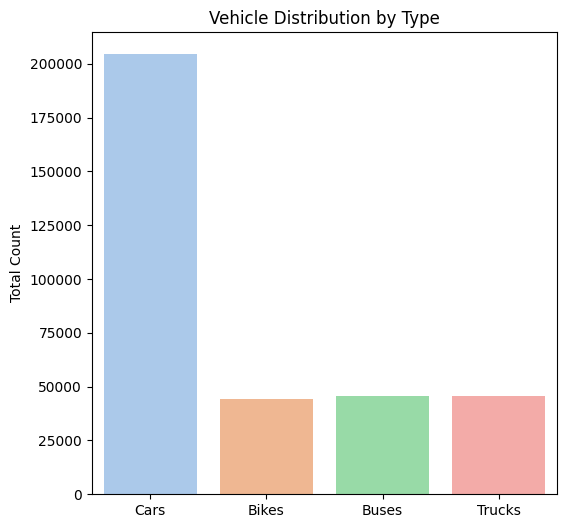

In [ ]:
#VISUALIZATIONS 1.Vehicle Distribution by Type
vehicle_counts = {
    'Cars': df['CarCount'].sum(),
    'Bikes': df['BikeCount'].sum(),
    'Buses': df['BusCount'].sum(),
    'Trucks': df['TruckCount'].sum()
}

plt.figure(figsize=(6,6))
sns.barplot(x=list(vehicle_counts.keys()), y=list(vehicle_counts.values()), palette="pastel")
plt.title("Vehicle Distribution by Type")
plt.ylabel("Total Count")
plt.show()

/tmp/ipython-input-533643737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Traffic Situation', data=df, palette="pastel")


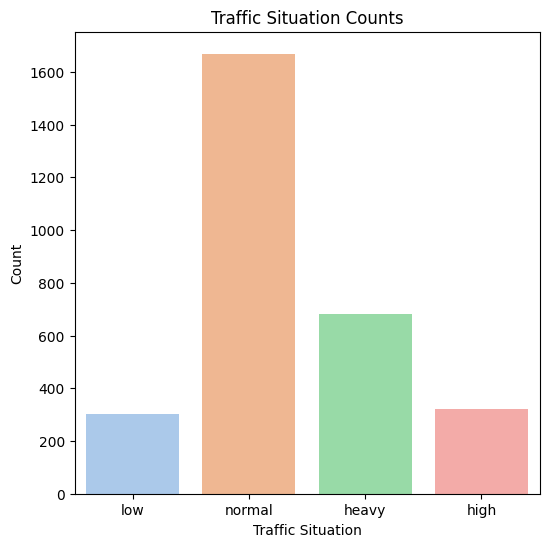

In [ ]:
#2.Traffic Situation Counts
plt.figure(figsize=(6,6))
sns.countplot(x='Traffic Situation', data=df, palette="pastel")
plt.title("Traffic Situation Counts")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-1925653239.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Peak', data=df, palette="pastel")


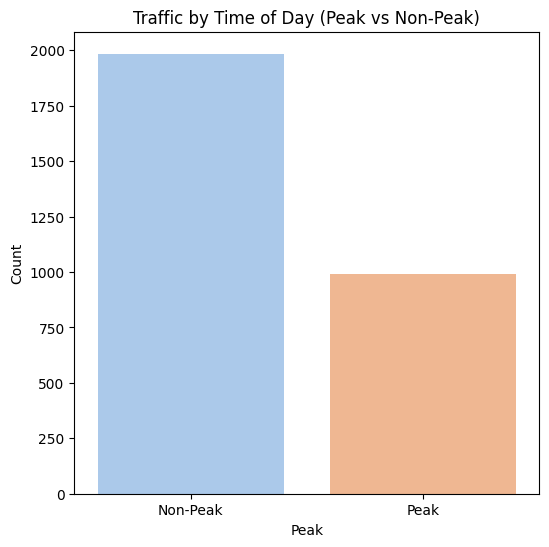

In [ ]:
#3 Traffic by time of day

df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['Peak'] = df['Hour'].apply(lambda x: 'Peak' if (7 <= x <= 10) or (16 <= x <= 19) else 'Non-Peak')

plt.figure(figsize=(6,6))
sns.countplot(x='Peak', data=df, palette="pastel")
plt.title("Traffic by Time of Day (Peak vs Non-Peak)")
plt.ylabel("Count")
plt.show()

  Day of the week  Total
0          Friday  41980
1          Monday  43376
2        Saturday  44486
3          Sunday  43913
4        Thursday  54990
5         Tuesday  55315
6       Wednesday  55854


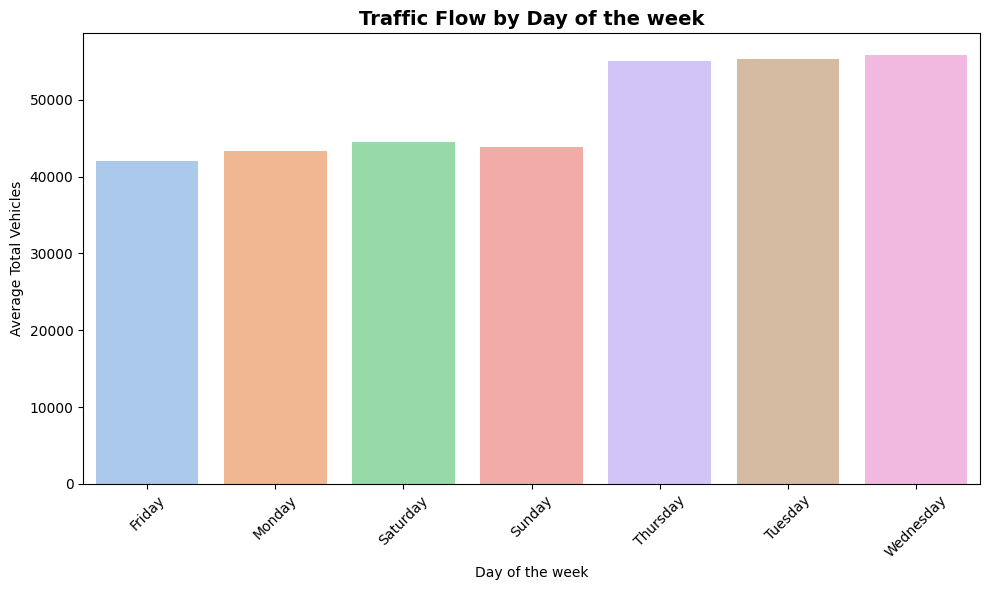

In [ ]:
#4 Traffic flow by day of the week
# Group data by Day of the week and calculate average total vehicles
traffic_by_day = df.groupby("Day of the week")["Total"].sum().reset_index()
print(traffic_by_day)
plt.figure(figsize=(10,6))
sns.barplot(x="Day of the week", y="Total", data=traffic_by_day, palette="pastel", hue="Day of the week", legend=False)

plt.title("Traffic Flow by Day of the week", fontsize=14, weight="bold")
plt.xlabel("Day of the week")
plt.ylabel("Average Total Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

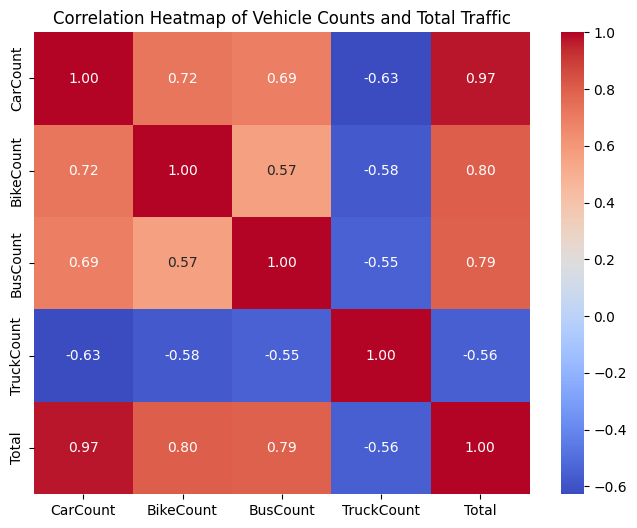

In [ ]:
#5 Coorelation Heat map of Vehicle counts and total traffic
plt.figure(figsize=(8,6))
corr = df[['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Vehicle Counts and Total Traffic")
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()

In [ ]:
df['Day of the week']=le1.fit_transform(df['Day of the week'])
df['Traffic Situation']=le2.fit_transform(df['Traffic Situation'])
df['Peak']=le2.fit_transform(df['Peak'])

df

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour,Peak
0,2025-11-13 00:00:00,10,5,31,0,4,4,39,2,0,0
1,2025-11-13 00:15:00,10,5,49,0,3,3,55,2,0,0
2,2025-11-13 00:30:00,10,5,46,0,3,6,55,2,0,0
3,2025-11-13 00:45:00,10,5,51,0,2,5,58,2,0,0
4,2025-11-13 01:00:00,10,5,57,6,15,16,94,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2971,2025-11-13 22:45:00,9,4,16,3,1,36,56,3,22,0
2972,2025-11-13 23:00:00,9,4,11,0,1,30,42,3,23,0
2973,2025-11-13 23:15:00,9,4,15,4,1,25,45,3,23,0
2974,2025-11-13 23:30:00,9,4,16,5,0,27,48,3,23,0


In [ ]:
x = df.drop(['Date', 'Time', 'Traffic Situation'], axis=1)
y = df['Traffic Situation']


In [ ]:
y.head(2)

,Traffic Situation
0,2
1,2


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y_train.head(2)

,Traffic Situation
1557,2
509,0


In [ ]:
y_test.head(2)

,Traffic Situation
2404,2
2866,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression()

In [ ]:
model1.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_predicted=model1.predict(x_test)

In [ ]:
y_predicted

array([2, 1, 3, 0, 3, 2, 3, 3, 3, 3, 0, 0, 2, 3, 2, 1, 1, 3, 3, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 3, 3, 2, 2, 3, 0, 1, 2, 3, 0, 3, 3, 3, 3,
       0, 3, 3, 3, 2, 2, 3, 0, 3, 3, 2, 3, 3, 3, 3, 3, 3, 0, 3, 2, 2, 3,
       3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 1, 1, 3, 3, 3, 0, 3, 0, 3, 3, 0,
       0, 0, 3, 3, 1, 3, 0, 0, 0, 3, 3, 3, 3, 3, 0, 3, 3, 3, 0, 3, 3, 3,
       0, 3, 1, 3, 0, 0, 3, 0, 2, 2, 3, 2, 0, 2, 3, 3, 2, 3, 0, 2, 3, 1,
       3, 0, 0, 3, 3, 2, 3, 0, 3, 1, 0, 1, 0, 1, 0, 0, 3, 0, 3, 0, 3, 3,
       2, 1, 3, 3, 3, 1, 0, 3, 3, 1, 0, 0, 0, 2, 3, 3, 3, 3, 3, 3, 3, 1,
       0, 3, 3, 3, 1, 2, 3, 3, 3, 3, 0, 3, 0, 1, 3, 3, 0, 0, 3, 3, 3, 0,
       1, 3, 3, 2, 2, 3, 3, 3, 2, 1, 3, 3, 3, 3, 3, 0, 3, 0, 3, 2, 3, 3,
       1, 3, 3, 2, 0, 3, 3, 3, 3, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0,
       3, 0, 3, 3, 3, 0, 1, 3, 3, 3, 2, 0, 3, 3, 1, 0, 1, 0, 3, 0, 3, 3,
       1, 3, 3, 3, 3, 0, 0, 0, 3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 1, 3,
       0, 3, 3, 0, 2, 0, 3, 0, 3, 3, 3, 3, 0, 0, 3,

In [ ]:
model1.predict_proba(x_test)

array([[3.95579166e-14, 1.50027667e-06, 8.03281503e-01, 1.96716997e-01],
       [6.64168201e-03, 5.96466762e-01, 4.20015813e-05, 3.96849554e-01],
       [5.08814639e-03, 2.10804336e-01, 8.15357109e-03, 7.75953947e-01],
       ...,
       [2.29784755e-10, 2.48815074e-03, 1.74656372e-04, 9.97337193e-01],
       [9.99393438e-01, 5.84044021e-04, 6.00733055e-08, 2.24575418e-05],
       [4.47633221e-10, 1.83279242e-02, 4.47010359e-05, 9.81627374e-01]])

In [ ]:
model1.score(x_test,y_test)

0.9010067114093959

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
accuracy_score(y_predicted,y_test)

0.9010067114093959

In [ ]:
confusion_matrix(y_predicted,y_test)

array([[126,   5,   0,   8],
       [  1,  44,   0,   5],
       [  0,   0,  50,  10],
       [  0,  14,  16, 317]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       127
           1       0.88      0.70      0.78        63
           2       0.83      0.76      0.79        66
           3       0.91      0.93      0.92       340

    accuracy                           0.90       596
   macro avg       0.88      0.85      0.86       596
weighted avg       0.90      0.90      0.90       596



In [ ]:
#DECISION TREE CLASSIFIER

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [ ]:
features=['X.columns, class_names=le_target.classes_, filled=True)']
plt.figure(figsize=(10,8))
plt.show()

<Figure size 1000x800 with 0 Axes>

In [ ]:
x_test

,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Hour,Peak
971,0,16,5,1,30,52,2,0
2458,2,105,20,20,11,156,14,0
1996,1,104,5,16,16,141,19,1
314,0,29,6,1,12,48,6,0
1626,4,16,4,0,35,55,22,0
...,...,...,...,...,...,...,...,...
2680,1,16,1,1,24,42,22,0
49,5,57,8,12,29,106,12,0
410,2,117,29,49,2,197,6,0
2393,0,19,3,1,35,58,22,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(max_depth=3)
dtree=dtree.fit(x_train,y_train)

In [ ]:
model2=DecisionTreeClassifier()
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
y_pred=model2.predict(x_test)
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
model2.predict_proba(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

In [ ]:
model2.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.10234899328859061

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix
score=accuracy_score(y_pred,y_test)

In [ ]:
accuracy_score(y_predicted,y_test)

0.3875838926174497

In [ ]:
confusion_matrix(y_pred,y_test)

array([[  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [131,  54,  61, 350],
       [  0,   0,   0,   0]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.20      0.21      0.21       131
           1       0.10      0.09      0.10        54
           2       0.02      0.02      0.02        61
           3       0.57      0.56      0.57       350

    accuracy                           0.39       596
   macro avg       0.22      0.22      0.22       596
weighted avg       0.39      0.39      0.39       596



In [ ]:
#RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier()

In [ ]:
model3.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_predicted=model3.predict(x_test)
y_predicted

array([3, 3, 3, 2, 3, 0, 3, 0, 1, 3, 0, 3, 3, 1, 0, 3, 3, 3, 1, 0, 3, 1,
       3, 3, 3, 1, 3, 2, 2, 3, 3, 2, 0, 0, 3, 3, 3, 0, 3, 3, 2, 0, 3, 3,
       2, 3, 3, 3, 3, 3, 1, 3, 3, 2, 3, 0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3,
       1, 3, 3, 3, 0, 3, 3, 0, 0, 3, 0, 1, 3, 1, 3, 3, 1, 3, 3, 0, 0, 0,
       3, 1, 0, 3, 2, 3, 3, 0, 2, 3, 3, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 3, 0, 3, 3, 3, 0, 0, 3, 3, 0, 0, 0, 3, 3, 0, 3, 2, 3, 3,
       3, 0, 3, 1, 3, 3, 3, 0, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3,
       3, 1, 0, 0, 3, 0, 3, 3, 0, 3, 3, 3, 2, 3, 3, 0, 0, 3, 3, 3, 0, 3,
       3, 3, 3, 3, 0, 2, 3, 3, 0, 3, 3, 3, 1, 3, 0, 2, 3, 3, 2, 3, 3, 0,
       1, 3, 3, 3, 3, 3, 0, 0, 2, 0, 0, 0, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3,
       3, 0, 3, 3, 3, 3, 0, 0, 2, 3, 1, 3, 3, 2, 3, 1, 0, 0, 3, 3, 3, 0,
       1, 2, 2, 2, 1, 3, 3, 0, 0, 0, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 3,
       1, 0, 3, 2, 3, 1, 2, 2, 2, 3, 2, 3, 3, 3, 0,

In [ ]:
model3.predict_proba(x_test)

array([[0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.03, 0.  , 0.97],
       [0.  , 0.17, 0.01, 0.82],
       ...,
       [0.99, 0.  , 0.  , 0.01],
       [0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 1.  ]])

In [ ]:
model3.score(x_test,y_test)

0.9932885906040269

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
accuracy_score(y_predicted,y_test)

0.9932885906040269

In [ ]:
confusion_matrix(y_predicted,y_test)

array([[131,   0,   0,   3],
       [  0,  54,   0,   1],
       [  0,   0,  61,   0],
       [  0,   0,   0, 346]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       131
           1       0.98      1.00      0.99        54
           2       1.00      1.00      1.00        61
           3       1.00      0.99      0.99       350

    accuracy                           0.99       596
   macro avg       0.99      1.00      0.99       596
weighted avg       0.99      0.99      0.99       596



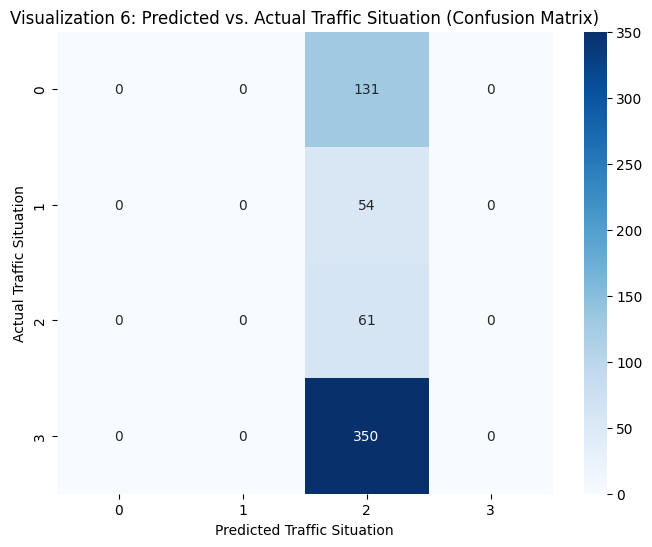

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Visualization 6: Predicted vs. Actual Traffic Situation (Confusion Matrix)')
plt.ylabel('Actual Traffic Situation')
plt.xlabel('Predicted Traffic Situation')
plt.show()

In [ ]:
#SUPPORT VECTOR MACHINE-SUPPORT VECTOR CLASSIFIER

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.svm import SVC
model4=SVC(kernel='rbf')
model4.fit(x_train,y_train)

SVC()

In [ ]:
y_predicted=model4.predict(x_test)
y_predicted

array([3, 3, 3, 2, 3, 0, 3, 0, 1, 3, 0, 3, 3, 1, 0, 3, 3, 3, 1, 0, 3, 1,
       3, 3, 3, 1, 3, 2, 2, 3, 3, 2, 0, 0, 3, 3, 3, 0, 3, 3, 3, 0, 2, 3,
       3, 3, 3, 3, 3, 3, 1, 3, 3, 2, 3, 0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3,
       1, 3, 3, 3, 0, 3, 3, 0, 0, 3, 0, 1, 3, 1, 3, 3, 1, 3, 3, 0, 0, 0,
       3, 1, 0, 3, 3, 3, 3, 0, 2, 3, 3, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 3, 0, 3, 3, 3, 0, 0, 3, 3, 0, 0, 0, 3, 3, 0, 3, 2, 2, 3,
       3, 0, 3, 1, 3, 3, 3, 0, 3, 3, 3, 3, 2, 2, 3, 3, 2, 3, 3, 3, 3, 3,
       3, 3, 0, 0, 3, 0, 3, 3, 0, 3, 3, 3, 2, 3, 3, 0, 0, 3, 3, 3, 0, 3,
       3, 3, 3, 3, 0, 2, 3, 3, 0, 3, 3, 3, 3, 3, 0, 2, 3, 3, 3, 3, 3, 0,
       1, 3, 3, 3, 3, 3, 0, 0, 2, 0, 1, 0, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3,
       3, 0, 3, 3, 3, 3, 0, 0, 2, 3, 1, 3, 3, 2, 3, 1, 0, 0, 3, 3, 2, 0,
       1, 2, 3, 2, 1, 3, 3, 0, 0, 0, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 3,
       0, 0, 3, 2, 3, 0, 3, 3, 2, 3, 2, 3, 3, 3, 0,

In [ ]:
model4.score(x_test,y_test)

0.9446308724832215

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
accuracy_score(y_predicted,y_test)

0.9446308724832215

In [ ]:
confusion_matrix(y_predicted,y_test)

array([[130,   3,   0,   4],
       [  1,  44,   0,   1],
       [  0,   0,  52,   8],
       [  0,   7,   9, 337]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [ ]:
print(classification_report (y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       131
           1       0.96      0.81      0.88        54
           2       0.87      0.85      0.86        61
           3       0.95      0.96      0.96       350

    accuracy                           0.94       596
   macro avg       0.93      0.91      0.92       596
weighted avg       0.94      0.94      0.94       596



In [ ]:
day = input("Enter Day (e.g., Monday, Tuesday): ")
time = float(input("Enter Time in 24-hour format (e.g., 8 for 8 AM, 17 for 5 PM): "))

if 7 <= time <= 9 or 17 <= time <= 19:
    print("Traffic Condition: High")
elif 10 <= time <= 16:
    print("Traffic Condition: Normal")
else:
    print("Traffic Condition: Low")


Enter Day (e.g., Monday, Tuesday): tuesday
Enter Time in 24-hour format (e.g., 8 for 8 AM, 17 for 5 PM): 15
Traffic Condition: Normal
